# Model Complexity and Regression Geometry

## Research Question
### How does model complexity affect the geometry of regression functions and their ability to generalize?



We investigate this by comparing polynomial regression and decision tree regression while systematically increasing their complexity.

In [50]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')

## Background: Regression Models and Model Complexity

### Polynomial Regression
Polynomial regression fits a polynomial of degree $d$ to the data:
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

**How it controls complexity:** The degree $d$ determines the number of parameters. Higher degree → more parameters → more flexibility to fit complex patterns, but also more risk of overfitting to noise.

### Decision Tree Regression
A decision tree recursively partitions the input space into axis-aligned regions, predicting the mean target value in each region.

**How it controls complexity:** The maximum depth limits tree growth. Greater depth → more splits → finer partitions of the input space → greater capacity to fit local patterns.

### The Fundamental Challenge: The Bias-Variance Tradeoff
Both models face the same core problem: **as we increase model complexity, training error decreases but test error often increases** due to overfitting. This is driven by the bias-variance decomposition of prediction error.

---

## Dataset

We generate a synthetic dataset based on a known function to evaluate how well models approximate the true relationship.

**Choose one of the four options below depending on what pattern you want to demonstrate.**

### Simple sinus 

In [51]:
np.random.seed(0)

X = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.2, size=X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Mixed-frequency function

In [47]:
np.random.seed(0)

X = np.linspace(-3, 3, 200).reshape(-1, 1)

y_true = (
    np.sin(X).ravel() 
    + 0.5 * np.sin(3 * X).ravel() 
    + 0.2 * X.ravel()
)

y = y_true + np.random.normal(0, 0.2, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Nonlinear + sharp change

In [48]:
y_true = np.where(
    X.ravel() < 0,
    np.sin(X).ravel(),
    0.5 * X.ravel()**2
)

y = y_true + np.random.normal(0, 0.2, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Complex function -> good for showing overfitting

In [49]:
y_true = np.sin(2 * X).ravel() + 0.3 * np.cos(5 * X).ravel()
y = y_true + np.random.normal(0, 0.3, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Polynomial Regression

We increase the degree of the polynomial to control model complexity.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

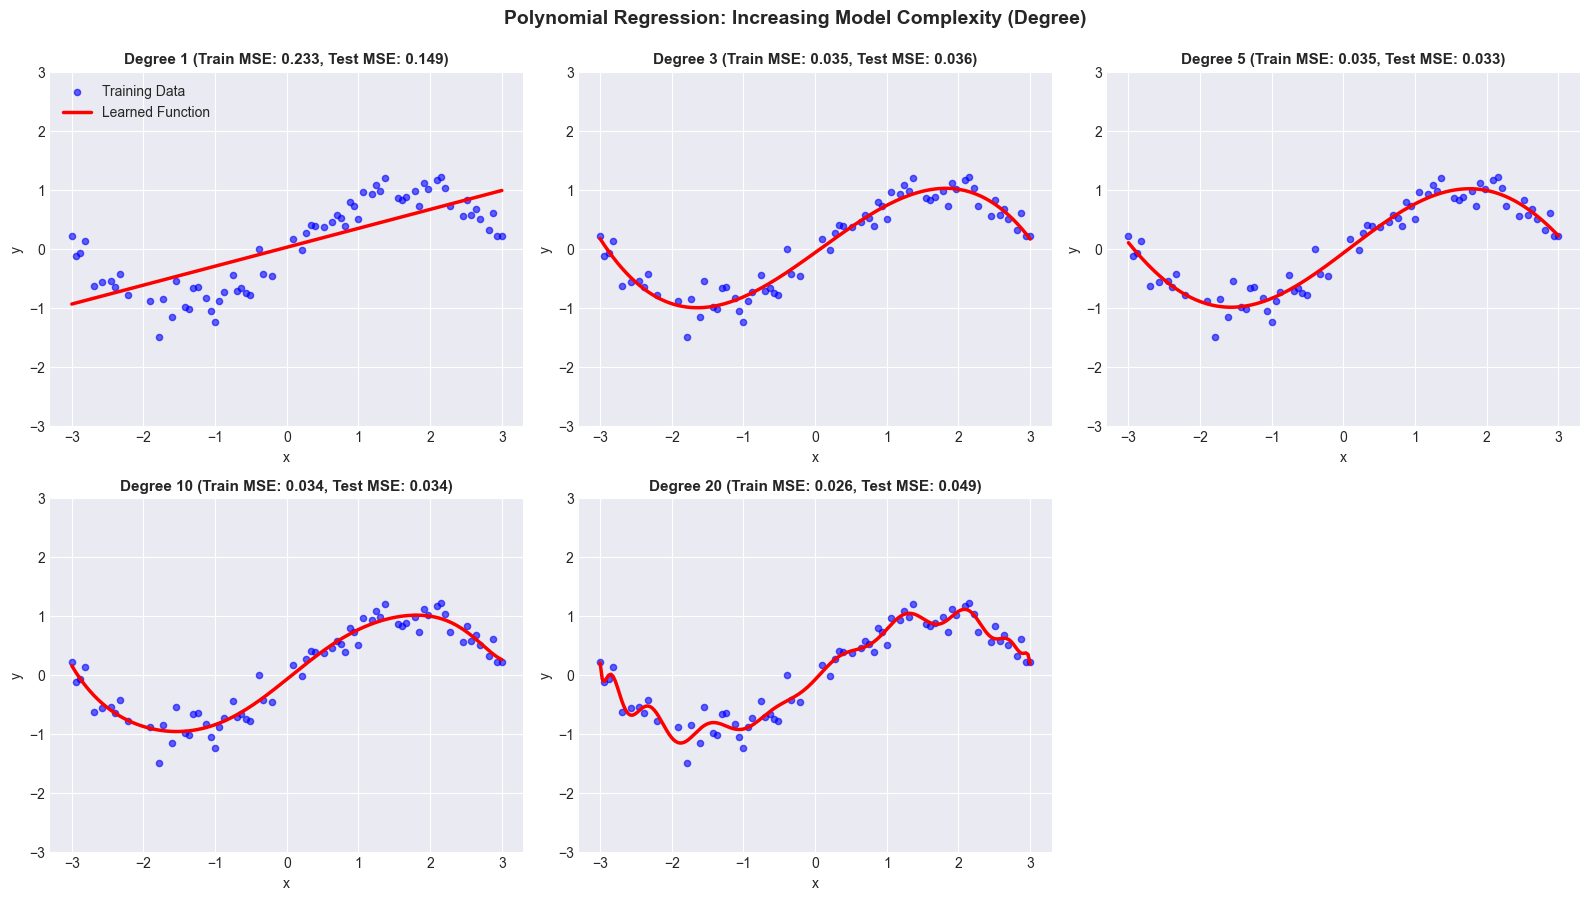

In [52]:
degrees = [1, 3, 5, 10, 20]

train_errors = []
test_errors = []

plt.figure(figsize=(16, 9))

for i, d in enumerate(degrees):
    poly = PolynomialFeatures(degree=d)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    y_train_pred = model.predict(X_poly_train)
    y_test_pred = model.predict(X_poly_test)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

    # Plot
    plt.subplot(2, 3, i+1)
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.scatter(X_train, y_train, color='blue', s=20, alpha=0.6, label='Training Data')
    plt.plot(X_plot, y_plot, color='red', linewidth=2.5, label='Learned Function')
    plt.title(f"Degree {d} (Train MSE: {train_errors[i]:.3f}, Test MSE: {test_errors[i]:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-3, 3)
    if i == 0:
        plt.legend(loc='upper left')

plt.suptitle('Polynomial Regression: Increasing Model Complexity (Degree)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

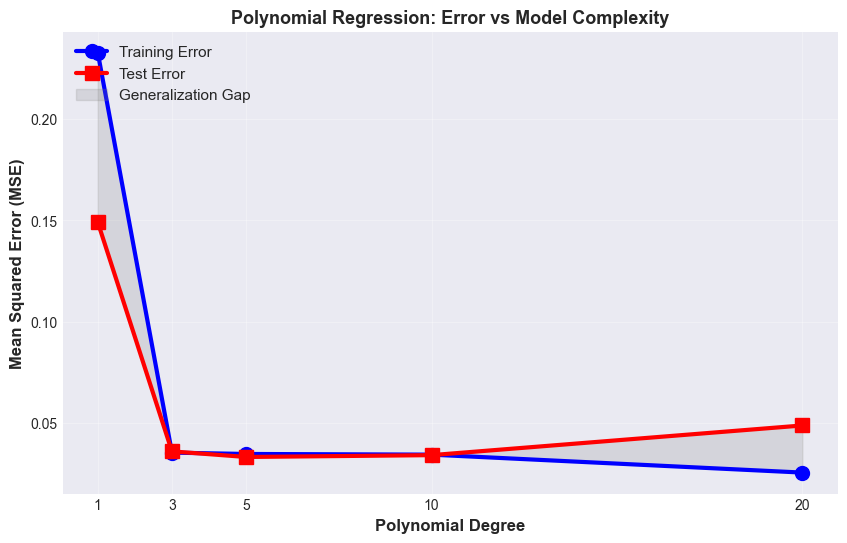


Observation: Test error initially decreases (good fit) but then increases (overfitting).


In [53]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', linewidth=3, markersize=10, label="Training Error", color='blue')
plt.plot(degrees, test_errors, 's-', linewidth=3, markersize=10, label="Test Error", color='red')
plt.fill_between(degrees, train_errors, test_errors, alpha=0.2, color='gray', label='Generalization Gap')
plt.xlabel("Polynomial Degree", fontsize=12, fontweight='bold')
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold')
plt.title("Polynomial Regression: Error vs Model Complexity", fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.show()

print("\nObservation: Test error initially decreases (good fit) but then increases (overfitting).")

## Decision Tree Regression

We increase the maximum depth to control complexity.

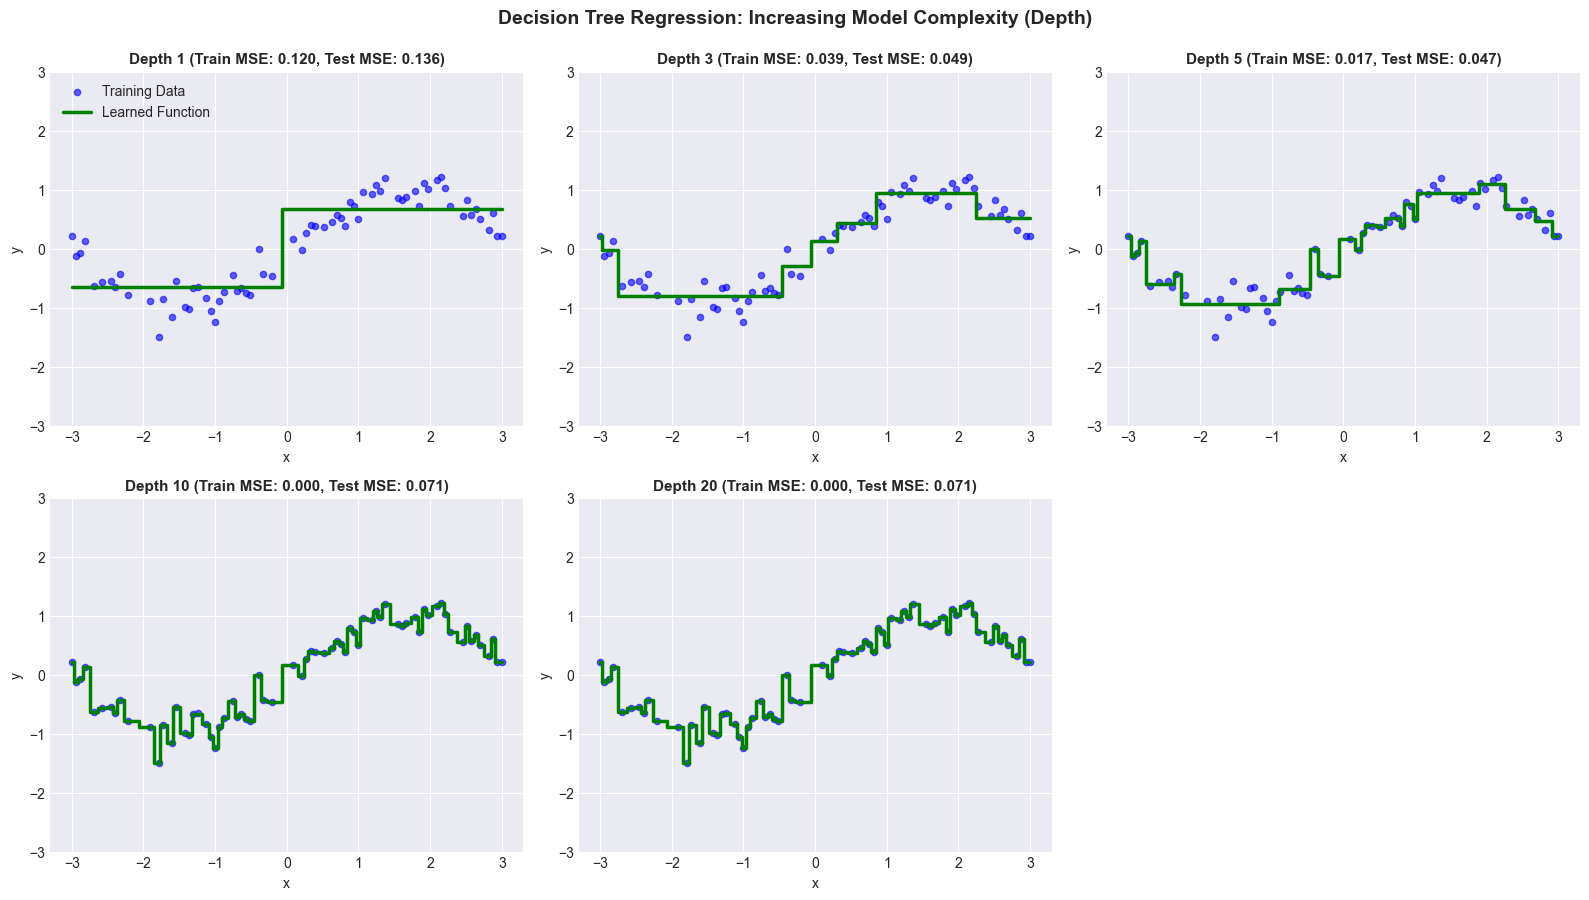

In [54]:
depths = [1, 3, 5, 10, 20]

train_errors_tree = []
test_errors_tree = []

plt.figure(figsize=(16, 9))

for i, d in enumerate(depths):
    model = DecisionTreeRegressor(max_depth=d, random_state=0)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors_tree.append(mean_squared_error(y_train, y_train_pred))
    test_errors_tree.append(mean_squared_error(y_test, y_test_pred))

    # Plot
    plt.subplot(2, 3, i+1)
    X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.scatter(X_train, y_train, color='blue', s=20, alpha=0.6, label='Training Data')
    plt.step(X_plot, y_plot, color='green', linewidth=2.5, where='mid', label='Learned Function')
    plt.title(f"Depth {d} (Train MSE: {train_errors_tree[i]:.3f}, Test MSE: {test_errors_tree[i]:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-3, 3)
    if i == 0:
        plt.legend(loc='upper left')

plt.suptitle('Decision Tree Regression: Increasing Model Complexity (Depth)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

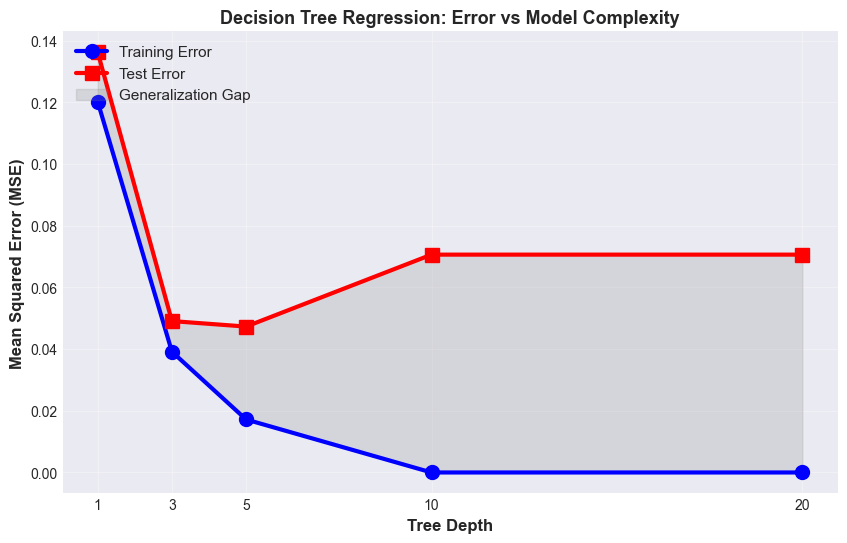

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors_tree, 'o-', linewidth=3, markersize=10, label="Training Error", color='blue')
plt.plot(depths, test_errors_tree, 's-', linewidth=3, markersize=10, label="Test Error", color='red')
plt.fill_between(depths, train_errors_tree, test_errors_tree, alpha=0.2, color='gray', label='Generalization Gap')
plt.xlabel("Tree Depth", fontsize=12, fontweight='bold')
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold')
plt.title("Decision Tree Regression: Error vs Model Complexity", fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()

# print("\nObservation: Both models show the same pattern—optimal generalization at moderate complexity.")

## Analysis

We observe that increasing model complexity reduces training error for both models.

However, test error follows a U-shaped curve:
- Low complexity leads to underfitting
- High complexity leads to overfitting

Polynomial regression produces smooth but highly oscillatory curves at high degrees.

Decision trees produce piecewise constant functions that become increasingly fragmented as depth increases.


## Conclusion: How Complexity Affects Geometry and Generalization

### Main Findings

**1. Geometry Changes with Complexity:**
- **Polynomials**: Become increasingly oscillatory with higher degree. While they maintain global smoothness, the curvature grows dramatically, producing wild oscillations that fit noise in the training data.
- **Decision Trees**: Become increasingly fragmented. Each increase in depth creates finer partitions of the input space, transitioning from coarse step-like regions to highly localized piecewise-constant surfaces.

**2. The Bias-Variance Tradeoff:**
- **Low complexity** (underfitting): High bias → systematic errors, but low variance across different training sets. Models are stable but oversimplify the true function.
- **High complexity** (overfitting): Low bias → fits training data well, but high variance → predictions vary wildly with small changes to training data. Models overfit to noise.

**3. Generalization Gap:**
The difference between training and test error (generalization gap) grows with model complexity:
- At moderate complexity: gap is small (good generalization)
- At very high complexity: gap becomes large (overfitting)

**4. Regularization as Geometry Control:**
Regularization (Ridge penalty, min_samples_leaf) constrains the hypothesis space by:
- For polynomials: penalizing large coefficients → smoother functions with lower oscillations
- For trees: preventing fine splits → larger, more stable regions

Both approaches recover the generalization sweet spot by trading some bias for much less variance.

### Answer to Research Question

**Model complexity fundamentally alters the learned geometry of regression functions and their generalization ability:**

1. **Geometric Properties**: Different model classes show distinct geometric behaviors when complexity increases. Polynomials oscillate globally; trees fragment locally.

2. **Optimal Complexity**: Neither high nor low complexity is ideal. The optimal model uses just enough complexity to capture the true underlying pattern without fitting noise. This is the essence of the bias-variance tradeoff.

3. **Generalization**: Models that generalize best balance fitting the signal while remaining insensitive to noise. This requires constraining complexity through regularization or explicit model selection.

4. **Practical Implication**: We cannot simply choose the most complex model. Instead, we must evaluate models on held-out test data and select the one with the best generalization performance, which typically occurs at moderate complexity levels.